In [1]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import datetime
from pathlib import Path
from os import path

from rasterio.plot import plotting_extent
from matplotlib.colors import ListedColormap

import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Observation

Min: -10.689999999999998
Max: 70.51000000000005
Total pixels: 7438848
NaN count: 2912340 ( 39.15 %)


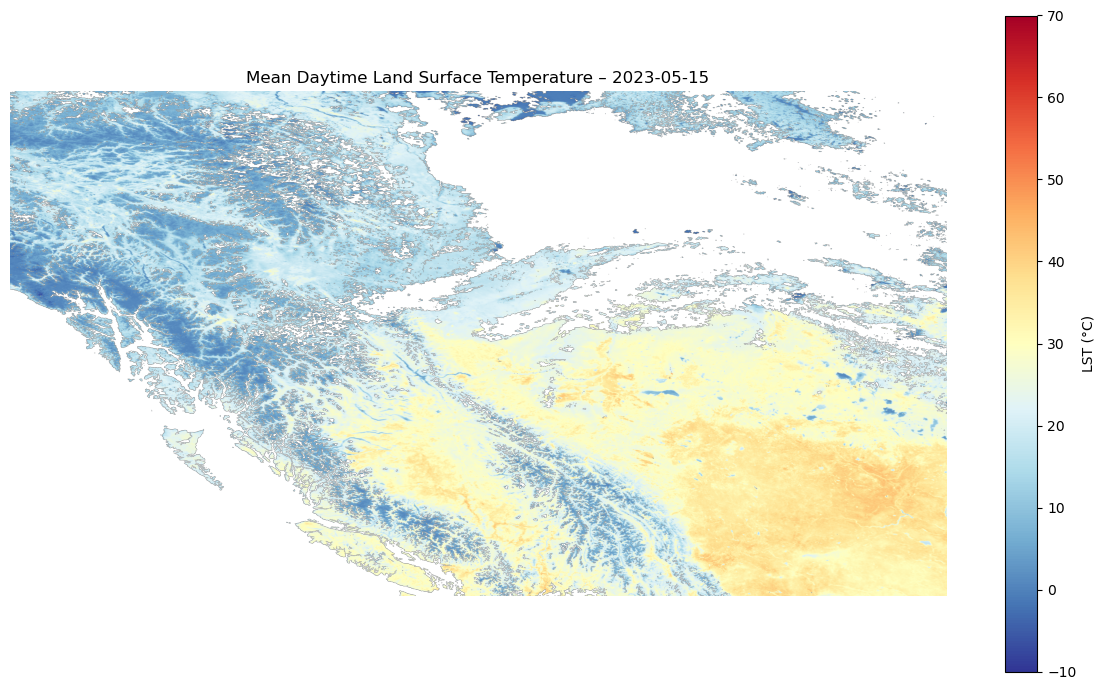

In [2]:
path = Path("/Volumes/Scratch/jchen/GEE/meanDaytimeLST_colorized_2023-05-15.tif")

# Mean Daytime Land Surface Temperature (LST) in °C
with rasterio.open(path) as src:
    band = src.read(1).astype(float)

    print('Min:', np.nanmin(band))
    print('Max:', np.nanmax(band))
    print('Total pixels:', band.size)
    nan_ratio = np.round(np.sum(np.isnan(band)) / band.size * 100, 2)
    print('NaN count:', np.sum(np.isnan(band)), '(', nan_ratio, '%)')

    band[band == 0] = np.nan  # mask any zero-nodata

plt.figure(figsize=(12, 7))
plt.imshow(band, cmap='RdYlBu_r', vmin=-10, vmax=70)
plt.colorbar(label='LST (°C)')
plt.title('Mean Daytime Land Surface Temperature – 2023-05-15')
plt.axis('off')
plt.tight_layout()
plt.show()

Min: -10.689999999999998
Max: 70.51000000000005
Total pixels: 7438848
NaN count: 2912340 ( 39.15 %)


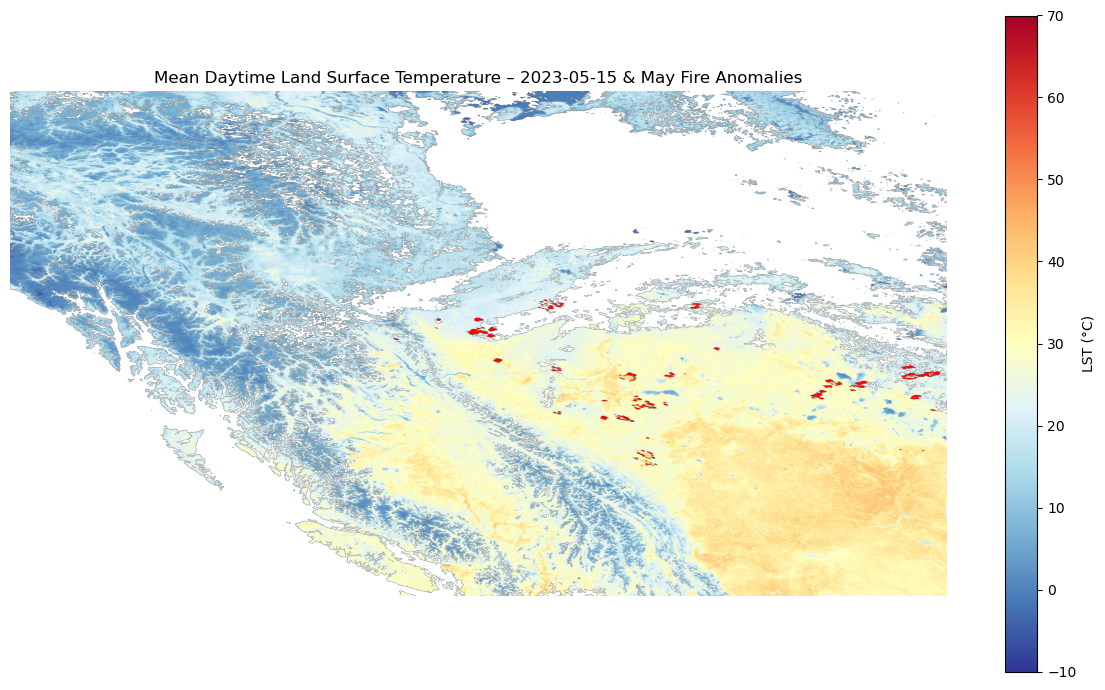

In [16]:
# I JUST WANT TO GENERATE IMAGES FOR ONE DAY

one_day = datetime.datetime(2023, 5, 15)

# Mean Daytime Land Surface Temperature (LST) in °C
with rasterio.open(f"/Volumes/Scratch/jchen/GEE/meanDaytimeLST_colorized_{one_day.strftime('%Y-%m-%d')}.tif") as src:
    temp_band = src.read(1).astype(float)
    temp_band_extent = plotting_extent(src)

    print('Min:', np.nanmin(temp_band))
    print('Max:', np.nanmax(temp_band))            
    print('Total pixels:', temp_band.size)
    nan_ratio = np.round(np.sum(np.isnan(temp_band)) / temp_band.size * 100, 2)
    print('NaN count:', np.sum(np.isnan(temp_band)), '(', nan_ratio, '%)')

    temp_band[temp_band == 0] = np.nan  # mask any zero-nodata

# Fire and Thermal Anomalies (one value per pixel, 0 for no fire, 1 for fire)
# FIRMS dataset is flagged as not science quality for quantitavtive analysis:
# https://developers.google.com/earth-engine/datasets/catalog/FIRMS
with rasterio.open(f"/Volumes/Scratch/jchen/GEE/Fire_and_Thermal_Anomalies_max_{one_day.strftime('%Y-%m-%d')}.tif") as src:
    fire = src.read(1).astype(float)
    fire_extent = plotting_extent(src)

    fire[fire == 0] = np.nan  # mask any zero-nodata
    fire_mask = np.where(np.isnan(fire), np.nan, 1)  # create a mask where fire is present

# Plotting
fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(temp_band, cmap='RdYlBu_r', vmin=-10, vmax=70)
plt.colorbar(im, ax=ax, label='LST (°C)')
ax.imshow(fire_mask, cmap=ListedColormap(['red']))  # overlay fire
ax.set_title(f'Mean Daytime Land Surface Temperature – {one_day.strftime("%Y-%m-%d")} & May Fire Anomalies')
plt.axis('off')
plt.tight_layout()
plt.show()



In [4]:
# ARE YOU READY TO GENERATE IMAGES FOR THE ENTIRE MAY-JUNE PERIOD
# Commented out for GitHub display

start = datetime.datetime(2023, 5, 1)
end = datetime.datetime(2023, 6, 19)

base_dir = Path("/Volumes/Scratch/jchen/GEE")
lst = "meanDaytimeLST_colorized_{date}.tif"
firms = "Fire_and_Thermal_Anomalies_max_{date}.tif"

# for date in range((end - start).days + 1):
#     date = start + datetime.timedelta(days=date)
#     lst_file = lst.format(date=date.strftime('%Y-%m-%d'))
#     firms_file = firms.format(date=date.strftime('%Y-%m-%d'))
#     path_lst = base_dir / lst_file
#     path_firms = base_dir / firms_file

#     if not path_lst.exists() or not path_firms.exists():
#         print(f"Missing files for {date.strftime('%Y-%m-%d')}")
#         continue

#     # Mean Daytime Land Surface Temperature (LST) in °C
#     with rasterio.open(path_lst) as src:
#         temp_band = src.read(1).astype(float)
#         temp_band_extent = plotting_extent(src)

#         print('Min:', np.nanmin(temp_band))
#         print('Max:', np.nanmax(temp_band))            
#         print('Total pixels:', temp_band.size)
#         nan_ratio = np.round(np.sum(np.isnan(temp_band)) / temp_band.size * 100, 2)
#         print('NaN count:', np.sum(np.isnan(temp_band)), '(', nan_ratio, '%)')

#         temp_band[temp_band == 0] = np.nan  # mask any zero-nodata
    
#     # Fire and Thermal Anomalies (one value per pixel, 0 for no fire, 1 for fire)
#     # FIRMS dataset is flagged as not science quality for quantitavtive analysis:
#     # https://developers.google.com/earth-engine/datasets/catalog/FIRMS
#     with rasterio.open(path_firms) as src:
#         fire = src.read(1).astype(float)
#         fire_extent = plotting_extent(src)

#         fire[fire == 0] = np.nan  # mask any zero-nodata
#         fire_mask = np.where(np.isnan(fire), np.nan, 1)  # create a mask where fire is present

#     # Plotting
#     fig, ax = plt.subplots(figsize=(12, 7))
#     im = ax.imshow(temp_band, cmap='RdYlBu_r', vmin=-10, vmax=70)
#     plt.colorbar(im, ax=ax, label='LST (°C)')
#     ax.imshow(fire_mask, cmap=ListedColormap(['red']))  # overlay fire
#     ax.set_title(f'Mean Daytime Land Surface Temperature – {date.strftime("%Y-%m-%d")} & May Fire Anomalies')
#     plt.axis('off')
#     plt.tight_layout()
#     plt.show()



In [5]:
# Check if .tif carries geographic information (lon, lat, elev)

tif = "/Volumes/Scratch/jchen/GEE/meanDaytimeLST_colorized_2023-05-15.tif"

with rasterio.open(tif) as src:
    print(f"  CRS        : {src.crs}")                    # coordinate system e.g. EPSG:4326
    print(f"  Transform  : {src.transform}")              # affine transform (pixel → geo coords)
    print(f"  Bounds     : {src.bounds}")                 # (left, bottom, right, top)
    print(f"  Resolution : {src.res}")                    # (x_res, y_res) in CRS units
    print(f"  Size       : {src.width} x {src.height}")  # pixels
    print(f"  Bands      : {src.count}")
    print(f"  Has CRS?   : {'YUUUUP' if src.crs else 'NO — missing geo info :('}")

    print(src.meta)

  CRS        : EPSG:4326
  Transform  : | 0.01, 0.00,-138.56|
| 0.00,-0.01, 66.21|
| 0.00, 0.00, 1.00|
  Bounds     : BoundingBox(left=-138.556149422595, bottom=48.20359814585352, right=-105.21068607607837, top=66.20583643960873)
  Resolution : (0.008983152841195215, 0.008983152841195215)
  Size       : 3712 x 2004
  Bands      : 1
  Has CRS?   : YUUUUP
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 3712, 'height': 2004, 'count': 1, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(0.008983152841195215, 0.0, -138.556149422595,
       0.0, -0.008983152841195215, 66.20583643960873)}


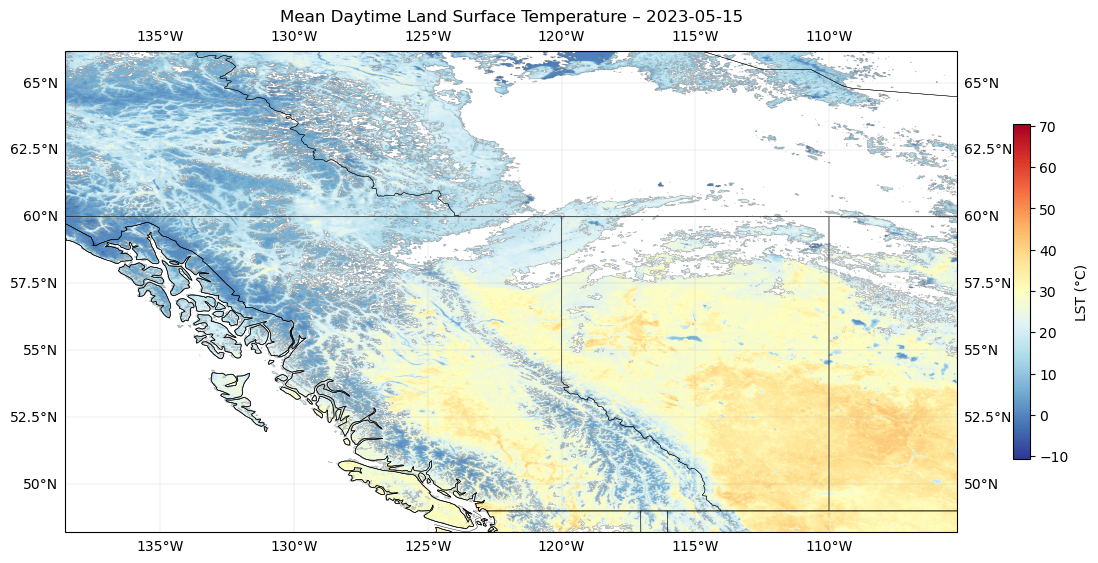

In [6]:
with rasterio.open(tif) as src:
    data = src.read(1).astype(float)
    nodata = src.nodata
    bounds = src.bounds
    height, width = data.shape

    # Build lon/lat grids, I hope this works
    cols, rows = np.meshgrid(np.arange(width), np.arange(height))
    xs, ys = rasterio.transform.xy(src.transform, rows, cols)
    lon = np.array(xs)
    lat = np.array(ys)

if nodata is not None: # Mask nodata values
    data = np.wehre(data == nodata, np.nan, data)

# Flatten for scatter, 2D -> 1D (optional)
# lon_flat = lon.flatten()
# lat_flat = lat.flatten()
# data_flat = data.flatten

# mask = ~np.isnan(data_flat)
# lon_flat  = lon_flat[mask]
# lat_flat  = lat_flat[mask]
# data_flat = data_flat[mask]

# Plot (same style as ai_forecast_sample.ipynb)
fig, ax = plt.subplots(figsize=(12, 6),
                       subplot_kw={'projection': ccrs.PlateCarree()})

# Flatten
# sc = ax.scatter(lon_flat, lat_flat, c=data_flat, s=0.5,
#                 transform=ccrs.PlateCarree(),
#                 cmap='RdYlBu_r')  

# No flatten
im = ax.imshow(data,
               origin='upper',
               extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
               transform=ccrs.PlateCarree(),
               cmap='RdYlBu_r')

ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS,   linewidth=0.3)
ax.add_feature(cfeature.STATES,    linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

plt.colorbar(im, ax=ax, label="LST (°C)", shrink=0.6)
ax.set_title("Mean Daytime Land Surface Temperature – 2023-05-15")
plt.tight_layout()
plt.show()

# AI Forecast

In [36]:
# AI forcast sample
ai_dir = "../sample/20220701T00.nc"
ai = xr.open_dataset(ai_dir, engine='netcdf4')

In [37]:
ai_tds = ai.sel(time=ai.time[0])
ai_var = '2t'
ai_data = ai_tds[ai_var].values - 273.15 # Convert to degree celcius
ai_lat  = ai_tds['latitude'].values
ai_lon  = ai_tds['longitude'].values

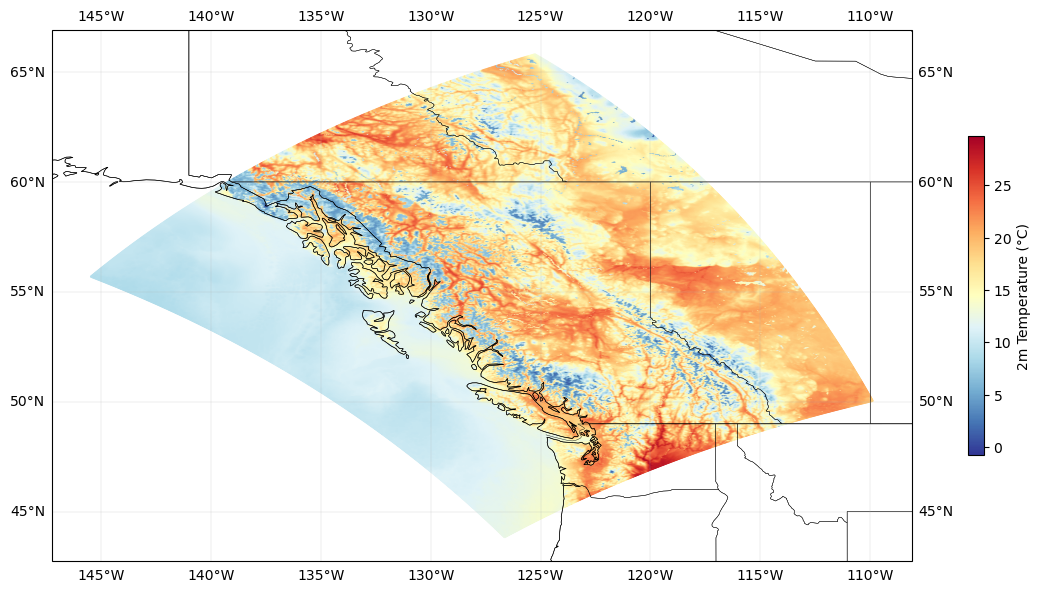

In [40]:
# AI plot
ai_fig, ai_ax = plt.subplots(figsize=(12, 6),
                       subplot_kw={'projection': ccrs.PlateCarree()})

ai_sc = ai_ax.scatter(ai_lon, ai_lat, c=ai_data, s=0.5, transform=ccrs.PlateCarree(),
                cmap='RdYlBu_r')

ai_ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ai_ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ai_ax.add_feature(cfeature.STATES, linewidth=0.3)
ai_ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

plt.colorbar(ai_sc, label='2m Temperature (°C)', shrink=0.6)
# ai_ax.set_title(f'{ai_var} on {str(ai_tds.time.values)[:19]}')
ax.set_title("2m Temperature AI Forecast – 2022-07-01")
plt.tight_layout()
plt.show()

# WRF Forecast

In [49]:
# WRF
wrf_dir = "/Volumes/jchen/Share_Forecasts/WAC00WG-01/23051500/wrfout_d02_2023-05-15_03:00:00"
wrf = xr.open_dataset(wrf_dir, engine='netcdf4')

In [50]:
wrf_var = 'T2'
wrf_data = wrf[wrf_var].values - 273.15 # Convert to degree celcius
wrf_lat  = wrf['XLAT'].values
wrf_lon  = wrf['XLONG'].values

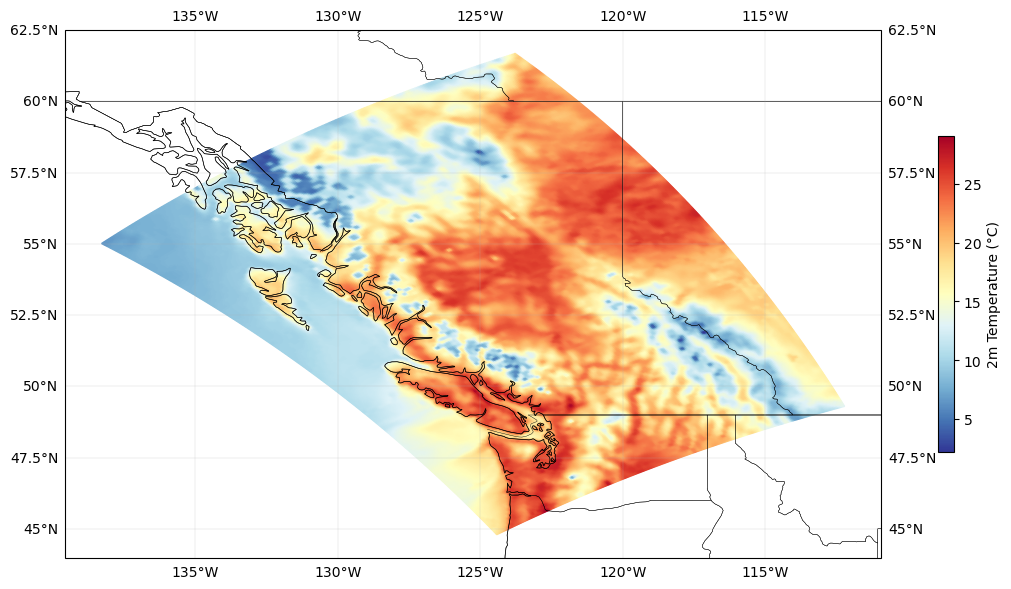

In [51]:
# WRF plot
wrf_fig, wrf_ax = plt.subplots(figsize=(12, 6),
                       subplot_kw={'projection': ccrs.PlateCarree()})

wrf_sc = wrf_ax.scatter(wrf_lon, wrf_lat, c=wrf_data, s=0.5, transform=ccrs.PlateCarree(),
                cmap='RdYlBu_r')

wrf_ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
wrf_ax.add_feature(cfeature.BORDERS, linewidth=0.3)
wrf_ax.add_feature(cfeature.STATES, linewidth=0.3)
wrf_ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

plt.colorbar(wrf_sc, label='2m Temperature (°C)', shrink=0.6)
# wrf_ax.set_title(f'{ai_var} on {str(ai_tds.time.values)[:19]}')
ax.set_title("2m Temperature WRF Forecast – 2023-05-15")
plt.tight_layout()
plt.show()